# Odd-One-Out Experiment Pipeline
### CPSY 1950 — Computational Models of Human Behavior

This notebook evaluates LLMs on the **odd-one-out** task from Psych-101 (Binz et al., 2025), based on Hebart et al. (2020)'s THINGS dataset similarity judgments.

In each trial, three words are presented and assigned to keys **D**, **P**, and **H**. The participant (or model) picks the one that is **least similar** to the other two — the "odd one out."

**What this notebook does:**
1. Loads and parses odd-one-out trials from the Psych-101 dataset
2. Queries one or more LLMs via Brown's LiteLLM API at each trial
3. Extracts logprobs for options D, P, and H
4. Computes **NLL** (how surprised is the model by the human's choice?) and **top-1 accuracy**
5. Compares model choice distributions to human choice distributions
6. Visualizes alignment results

**References:**
- Binz et al. (2025). *Centaur: a foundation model of human cognition*
- Hebart et al. (2020). *Revealing the multidimensional mental representations of natural objects underlying human similarity judgements*

---
## 0. Setup

In [56]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [57]:
from openai import OpenAI
from dotenv import load_dotenv
from datasets import load_dataset
from tqdm import tqdm
from collections import defaultdict
import os
import re
import math
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

In [58]:
load_dotenv()

client = OpenAI(
    api_key=os.getenv("OPENAI_API_KEY"),
    base_url="https://litellm.ccv.brown.edu"
)

# Confirm available models
models = client.models.list()
for m in models.data:
    print(m.id)

gemini-3-flash-preview
claude-sonnet-4-5
gpt-5.4
gpt-oss
Llama-3.3-70B-Instruct
Mistral-Large-3
gpt-5.2
gpt-5.2-codex
gemini-2.5-pro
gemini-3.1-flash-lite-preview


---
## 1. Load Psych-101 Odd-One-Out Data

The odd-one-out experiment in Psych-101 is drawn from **Hebart et al. (2020)** and uses the THINGS object concept dataset. Participants see three words and pick which is least similar to the other two.

Trial format in the transcript:
```
D: piecrust, P: game, and H: bracelet. You press <<D>>.
```

We'll filter for this experiment and parse each trial into its (triplet, human_choice) pair.

In [59]:
# Load Psych-101 from HuggingFace (requires internet / no VPN restriction on HuggingFace)
# Stream to avoid downloading the full dataset
ds_stream = load_dataset("marcelbinz/Psych-101", split="train", streaming=True)

# Collect all odd-one-out rows
# The experiment name contains 'hebart' (Hebart et al. 2020)
odd_one_out_rows = []
MAX_PARTICIPANTS = 20  # Limit for demo; increase for full experiment

seen_participants = set()

for row in ds_stream:
    exp = row.get("experiment", "")
    if "hebart" in exp.lower() or "odd" in exp.lower():
        participant_id = row.get("participant_id", row.get("participant", None))
        if participant_id not in seen_participants:
            seen_participants.add(participant_id)
        if len(seen_participants) <= MAX_PARTICIPANTS:
            odd_one_out_rows.append(row)
    if len(seen_participants) > MAX_PARTICIPANTS:
        break

print(f"Found {len(odd_one_out_rows)} rows from {len(seen_participants)} participants")
if odd_one_out_rows:
    print("\nSample experiment name:", odd_one_out_rows[0].get("experiment"))
    print("\nSample text (first 500 chars):")
    print(odd_one_out_rows[0]["text"][:500])

Found 20 rows from 21 participants

Sample experiment name: hebart2023things/exp1.csv

Sample text (first 500 chars):
You will be presented with triplets of objects, which will be assigned to the keys B, J, and K.
In each trial, please indicate which object you think is the odd one out by pressing the corresponding key.
In other words, please choose the object that is the least similar to the other two.

B: prune, J: nail polish, and K: diskette. You press <<K>>.
B: ladle, J: water bottle, and K: pug. You press <<K>>.
B: punch, J: hair, and K: lollipop. You press <<J>>.
B: oar, J: mug, and K: macaroni. You pres


### 1b. Fallback: Scan for any odd-one-out experiment name

If the cell above returned 0 rows, the experiment name might differ from 'hebart'. Run this cell to discover the correct name.

In [61]:
# ONLY run this if the above returned 0 results
# It scans the first 10,000 rows and prints all unique experiment names

if len(odd_one_out_rows) == 0:
    print("No rows found. Scanning for experiment names...")
    ds_scan = load_dataset("marcelbinz/Psych-101", split="train", streaming=True)
    all_names = set()
    for i, row in enumerate(ds_scan):
        all_names.add(row.get("experiment", ""))
        if i > 10000:
            break
    print("\nAll experiment names found:")
    for name in sorted(all_names):
        print(" ", name)
else:
    print("Data loaded successfully — no need to scan.")

Data loaded successfully — no need to scan.


---
## 2. Parse Trials

Each row in Psych-101 is one participant's full transcript. We parse it into individual trials — each trial has:
- The three words assigned to D, P, H
- The human's choice (which key they pressed)

In [62]:
VALID_KEYS = {"B", "J", "K"}

# Regex pattern for the odd-one-out trial format:
# "B: prune, J: nail polish, and K: diskette. You press <<K>>."
TRIAL_PATTERN = re.compile(
    r"B:\s*([\w\s\-']+?),\s*J:\s*([\w\s\-']+?),\s*and\s*K:\s*([\w\s\-']+?)\s*\.\s*You press <<([BJK])>>",
    re.IGNORECASE
)

def parse_trials(text):
    """
    Parse a full participant transcript into individual odd-one-out trials.

    Returns a list of dicts:
        {
          'B': word_for_B,
          'J': word_for_J,
          'K': word_for_K,
          'human_choice': 'B' | 'J' | 'K'
        }
    """
    trials = []
    for m in TRIAL_PATTERN.finditer(text):
        word_B = m.group(1).strip()
        word_J = m.group(2).strip()
        word_K = m.group(3).strip()
        choice  = m.group(4).strip().upper()
        if choice in VALID_KEYS:
            trials.append({
                "B": word_B,
                "J": word_J,
                "K": word_K,
                "human_choice": choice
            })
    return trials


# Parse all participant transcripts and flatten into one list of trials
all_trials = []

for row in odd_one_out_rows:
    pid = row.get("participant_id", row.get("participant", "unknown"))
    trials = parse_trials(row["text"])
    for t in trials:
        t["participant_id"] = pid
    all_trials.extend(trials)

print(f"Total trials parsed: {len(all_trials)}")
if all_trials:
    print("\nExample trial:")
    print(all_trials[0])

Total trials parsed: 60

Example trial:
{'B': 'prune', 'J': 'nail polish', 'K': 'diskette', 'human_choice': 'K', 'participant_id': '0'}


In [63]:
# Human choice distribution across all trials
human_choices = [t["human_choice"] for t in all_trials]
for key in VALID_KEYS:
    count = human_choices.count(key)
    print(f"  Key {key}: {count} ({100*count/len(human_choices):.1f}%)")

  Key K: 22 (36.7%)
  Key J: 15 (25.0%)
  Key B: 23 (38.3%)


---
## 3. Build the Prompt

We need to tell the model: here are three words, pick the odd one out and respond with **only a single letter: D, P, or H**.

We use `logprobs=True` and `top_logprobs=5` to capture the model's probability distribution over D/P/H, not just which one it picked.

In [17]:
ODD_ONE_OUT_SYSTEM_PROMPT = """You are participating in a cognitive psychology experiment.

On each trial you will see three words assigned to three keys: B, J, and K.
Your task is to identify which word is the ODD ONE OUT — the word that is least similar to the other two.

Respond with ONLY a single uppercase letter: B, J, or K.
Do not explain your answer. Do not output anything else."""


def build_trial_prompt(trial):
    """
    Build the user-turn message for a single odd-one-out trial.
    Matches the Psych-101 transcript format closely.
    """
    return (
        f"B: {trial['B']}, J: {trial['J']}, and K: {trial['K']}.\n"
        f"Which is the odd one out? (B, J, or K)"
    )


# Preview
print("--- System prompt ---")
print(ODD_ONE_OUT_SYSTEM_PROMPT)
print("\n--- Example user prompt ---")
print(build_trial_prompt(all_trials[0]))

--- System prompt ---
You are participating in a cognitive psychology experiment.

On each trial you will see three words assigned to three keys: B, J, and K.
Your task is to identify which word is the ODD ONE OUT — the word that is least similar to the other two.

Respond with ONLY a single uppercase letter: B, J, or K.
Do not explain your answer. Do not output anything else.

--- Example user prompt ---
B: prune, J: nail polish, and K: diskette.
Which is the odd one out? (B, J, or K)


---
## 4. Logprob Extraction Utilities

We need to extract the logprobs the model assigns specifically to the tokens **D**, **P**, and **H**, whether or not they are the model's top predicted token. This gives us a full probability distribution over the three options for every trial.

In [64]:
def extract_option_logprobs(response, valid_tokens=("B", "J", "K")):
    """
    From an API response, extract the log-probability assigned to each
    valid option token (B, J, K) from the top-logprobs of the first generated token.

    Returns a dict like: {'B': -0.3, 'J': -1.2, 'K': -2.8}
    Tokens not found in top_logprobs are assigned -inf (probability ≈ 0).
    """
    top_lps = response.choices[0].logprobs.content[0].top_logprobs
    lp_map = {}

    for entry in top_lps:
        tok = entry.token.strip().upper()
        if tok in valid_tokens:
            if tok not in lp_map or entry.logprob > lp_map[tok]:
                lp_map[tok] = entry.logprob

    for tok in valid_tokens:
        if tok not in lp_map:
            lp_map[tok] = float("-inf")

    return lp_map


def get_model_choice(lp_map):
    """Return the model's top-1 choice (argmax over B/J/K)."""
    return max(lp_map, key=lp_map.get)


def get_nll(lp_map, human_choice):
    """
    Negative log-likelihood of the human's choice under the model's distribution.
    Returns float (lower = model was less surprised by the human's pick).
    """
    lp = lp_map.get(human_choice, float("-inf"))
    return -lp if not math.isinf(lp) else float("nan")


def softmax_from_logprobs(lp_map, valid_tokens=("B", "J", "K")):
    """
    Re-normalize log-probabilities over only the three valid tokens.
    Returns a dict of normalized probabilities.
    """
    log_vals = np.array([lp_map.get(t, float("-inf")) for t in valid_tokens], dtype=float)
    log_vals -= np.nanmax(log_vals[np.isfinite(log_vals)])
    probs = np.exp(log_vals)
    probs /= probs.sum()
    return {t: float(p) for t, p in zip(valid_tokens, probs)}

---
## 5. Run the Experiment

We query one or more models across a subset of trials.

**Configuration parameters:**
- `MODELS_TO_TEST`: list of model IDs to compare
- `N_TRIALS`: how many trials to run per model (start small to debug)

Each API call:
1. Sends the system prompt + trial prompt
2. Requests `logprobs=True, top_logprobs=5`
3. Records the logprobs for D, P, H and the human's actual choice

In [ ]:
# ── Configuration ────────────────────────────────────────────────────────────
MODELS_TO_TEST = [
    "Llama-3.3-70B-Instruct",
    # "gpt-5.2",   # add more models here
]

N_TRIALS    = 50
RANDOM_SEED = 42   # change or set to None for a different random draw each run
# ─────────────────────────────────────────────────────────────────────────────

random.seed(RANDOM_SEED)
trial_subset = random.sample(all_trials, min(N_TRIALS, len(all_trials)))

print(f"Selected {len(trial_subset)} trials randomly (seed={RANDOM_SEED})")
print(f"Running on {len(MODELS_TO_TEST)} model(s)...")

In [20]:
def run_odd_one_out(model_id, trials, verbose=False):
    """
    Query `model_id` on each trial in `trials`.

    Returns a list of result dicts, one per trial:
        {
          'trial_idx':     int,
          'B': str, 'J': str, 'K': str,
          'human_choice':  'B'|'J'|'K',
          'model_choice':  'B'|'J'|'K',
          'lp_B', 'lp_J', 'lp_K': raw logprobs,
          'prob_B', 'prob_J', 'prob_K': re-normalized probabilities,
          'nll':           float,
          'correct':       bool   (model top-1 == human)
        }
    """
    results = []

    for i, trial in enumerate(tqdm(trials, desc=model_id)):
        prompt = build_trial_prompt(trial)

        try:
            response = client.chat.completions.create(
                model=model_id,
                messages=[
                    {"role": "system", "content": ODD_ONE_OUT_SYSTEM_PROMPT},
                    {"role": "user",   "content": prompt}
                ],
                logprobs=True,
                top_logprobs=5,
                reasoning_effort=None,
                max_tokens=5
            )
        except Exception as e:
            print(f"  API error on trial {i}: {e}")
            continue

        lp_map      = extract_option_logprobs(response)
        prob_map    = softmax_from_logprobs(lp_map)
        model_choice = get_model_choice(lp_map)
        nll          = get_nll(lp_map, trial["human_choice"])

        result = {
            "trial_idx":    i,
            "B":            trial["B"],
            "J":            trial["J"],
            "K":            trial["K"],
            "human_choice": trial["human_choice"],
            "model_choice": model_choice,
            "lp_B":         lp_map["B"],
            "lp_J":         lp_map["J"],
            "lp_K":         lp_map["K"],
            "prob_B":       prob_map["B"],
            "prob_J":       prob_map["J"],
            "prob_K":       prob_map["K"],
            "nll":          nll,
            "correct":      model_choice == trial["human_choice"]
        }
        results.append(result)

        if verbose:
            print(f"  [{i}] B={trial['B']:15s} J={trial['J']:15s} K={trial['K']:15s} "
                  f"| Human={trial['human_choice']} Model={model_choice} "
                  f"NLL={nll:.3f}")

    return results

In [31]:
# Run all models and store results
all_results = {}  # model_id -> list of result dicts

for model_id in MODELS_TO_TEST:
    print(f"\n=== Running: {model_id} ===")
    results = run_odd_one_out(model_id, trial_subset, verbose=False)
    all_results[model_id] = results
    df = pd.DataFrame(results)
    print(f"  Top-1 accuracy (vs human): {df['correct'].mean():.3f}")
    print(f"  Mean NLL:                  {df['nll'].mean():.3f}")


=== Running: Llama-3.3-70B-Instruct ===


Llama-3.3-70B-Instruct: 100%|██████████████████████████████████████████████████████████████| 50/50 [00:30<00:00,  1.62it/s]

  Top-1 accuracy (vs human): 0.520
  Mean NLL:                  6.004


---
## 6. Analysis

### 6a. Summary statistics per model

In [32]:
summary_rows = []
for model_id, results in all_results.items():
    df = pd.DataFrame(results)
    summary_rows.append({
        "model":           model_id,
        "n_trials":        len(df),
        "top1_accuracy":   df["correct"].mean(),
        "mean_nll":        df["nll"].mean(),
        "median_nll":      df["nll"].median(),
        "chance_acc":      1/3,  # random baseline
        "chance_nll":      math.log(3),  # -log(1/3)
    })

summary_df = pd.DataFrame(summary_rows)
print(summary_df.to_string(index=False))

                 model  n_trials  top1_accuracy  mean_nll  median_nll  chance_acc  chance_nll
Llama-3.3-70B-Instruct        50           0.52  6.004439    0.114318    0.333333    1.098612


### 6b. Choice distribution: model vs. human

If a model's choices are uniformly distributed across D/P/H but humans prefer certain options, that's a sign of misalignment even if accuracy is decent.

In [33]:
# Human choice distribution on the same trial subset
human_choice_dist = {
    k: sum(1 for t in trial_subset if t["human_choice"] == k) / len(trial_subset)
    for k in VALID_KEYS
}
print("Human choice distribution:", {k: f"{v:.3f}" for k, v in human_choice_dist.items()})

for model_id, results in all_results.items():
    df = pd.DataFrame(results)
    model_dist = {k: (df["model_choice"] == k).mean() for k in VALID_KEYS}
    print(f"{model_id} distribution:", {k: f"{v:.3f}" for k, v in model_dist.items()})

Human choice distribution: {'K': '0.360', 'J': '0.280', 'B': '0.360'}
Llama-3.3-70B-Instruct distribution: {'K': '0.340', 'J': '0.160', 'B': '0.500'}


### 6c. Confusion matrix: human choice vs. model choice

Shows where the model agrees and disagrees with humans across each option.

In [34]:
keys = list(VALID_KEYS)

for model_id, results in all_results.items():
    df = pd.DataFrame(results)
    confusion = pd.crosstab(
        df["human_choice"].rename("Human →"),
        df["model_choice"].rename(f"{model_id} ↓"),
        normalize="index"
    ).reindex(index=keys, columns=keys, fill_value=0)
    print(f"\nConfusion matrix (row=human, col=model) — {model_id}")
    print(confusion.round(3).to_string())


Confusion matrix (row=human, col=model) — Llama-3.3-70B-Instruct
Llama-3.3-70B-Instruct ↓      K      J      B
Human →                                      
K                         0.611  0.056  0.333
J                         0.143  0.286  0.571
B                         0.222  0.167  0.611


---
## 7. Visualization

In [65]:
def plot_results(df, model_id, method_label="logprobs", save_path=None):
    """
    Reusable 3-panel figure for any odd-one-out results DataFrame.

    Works for both logprob-based results (run_odd_one_out / run_odd_one_out_vision)
    and sampling-based results (run_odd_one_out_sampling).

    Panels:
      Left  — NLL per trial with rolling average and chance baseline
      Center — choice distribution: human vs. model
      Right — histogram of model's probability assigned to the human's choice
    """
    nlls         = df["nll"].values.astype(float)
    trial_nums   = df["trial_idx"].values
    chance_nll   = math.log(3)

    human_dist = {k: (df["human_choice"] == k).mean() for k in sorted(VALID_KEYS)}
    model_dist = {k: (df["model_choice"] == k).mean() for k in sorted(VALID_KEYS)}

    human_probs_for_choice = [
        row[f"prob_{row['human_choice']}"] for _, row in df.iterrows()
    ]

    fig = plt.figure(figsize=(16, 5))
    gs  = gridspec.GridSpec(1, 3, wspace=0.38)
    title_base = f"{model_id}  [{method_label}]"

    # ── Panel 1: NLL per trial ────────────────────────────────────────────
    ax1 = fig.add_subplot(gs[0])
    ax1.scatter(trial_nums, nlls, alpha=0.45, s=25, color="steelblue",
                label="Trial NLL", zorder=3)
    window = min(10, len(nlls))
    if window > 1:
        valid_nlls = np.where(np.isnan(nlls), 0, nlls)
        rolling    = np.convolve(valid_nlls, np.ones(window) / window, mode="valid")
        ax1.plot(trial_nums[window - 1:], rolling, color="black",
                 linewidth=1.5, label=f"{window}-trial avg", zorder=4)
    ax1.axhline(np.nanmean(nlls), color="coral",  linestyle="--", linewidth=1.2,
                label=f"Mean NLL = {np.nanmean(nlls):.2f}")
    ax1.axhline(chance_nll,       color="gray",   linestyle=":",  linewidth=1.0,
                label=f"Chance NLL = {chance_nll:.2f}")
    ax1.set_xlabel("Trial")
    ax1.set_ylabel("NLL of Human's Choice")
    ax1.set_title(f"{title_base}\nNLL per Trial")
    ax1.legend(fontsize=8)

    # ── Panel 2: Choice distribution ─────────────────────────────────────
    ax2 = fig.add_subplot(gs[1])
    x, w = np.arange(len(VALID_KEYS)), 0.35
    keys_sorted = sorted(VALID_KEYS)
    ax2.bar(x - w / 2, [human_dist[k] for k in keys_sorted], w,
            label="Human", color="steelblue", alpha=0.8, edgecolor="black")
    ax2.bar(x + w / 2, [model_dist[k] for k in keys_sorted], w,
            label="Model", color="coral", alpha=0.8, edgecolor="black")
    ax2.axhline(1 / 3, color="gray", linestyle=":", linewidth=1, label="Chance (1/3)")
    ax2.set_xticks(x)
    ax2.set_xticklabels(keys_sorted)
    ax2.set_ylabel("Proportion of Choices")
    ax2.set_ylim(0, 0.85)
    ax2.set_title(f"{title_base}\nChoice Distribution")
    ax2.legend(fontsize=8)

    # ── Panel 3: Model confidence in human's answer ───────────────────────
    ax3 = fig.add_subplot(gs[2])
    ax3.hist(human_probs_for_choice, bins=20, color="mediumpurple",
             edgecolor="black", alpha=0.8)
    ax3.axvline(1 / 3, color="gray",  linestyle=":",  linewidth=1.5,
                label="Chance (0.33)")
    ax3.axvline(np.nanmean(human_probs_for_choice), color="black",
                linestyle="--", linewidth=1.5,
                label=f"Mean = {np.nanmean(human_probs_for_choice):.2f}")
    ax3.set_xlabel("Model's Probability for Human's Choice")
    ax3.set_ylabel("Count")
    ax3.set_title(f"{title_base}\nModel Confidence in Human's Answer")
    ax3.legend(fontsize=8)

    plt.suptitle("Odd-One-Out: LLM Alignment with Human Choices",
                 fontsize=13, fontweight="bold")
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
        print(f"Figure saved to {save_path}")

    plt.show()

/var/folders/s5/_m1bnhhx2ys3mzb1lzg0wxg00000gn/T/ipykernel_9539/1652615681.py:79: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Figure saved to odd_one_out_Llama-3.3-70B-Instruct.png


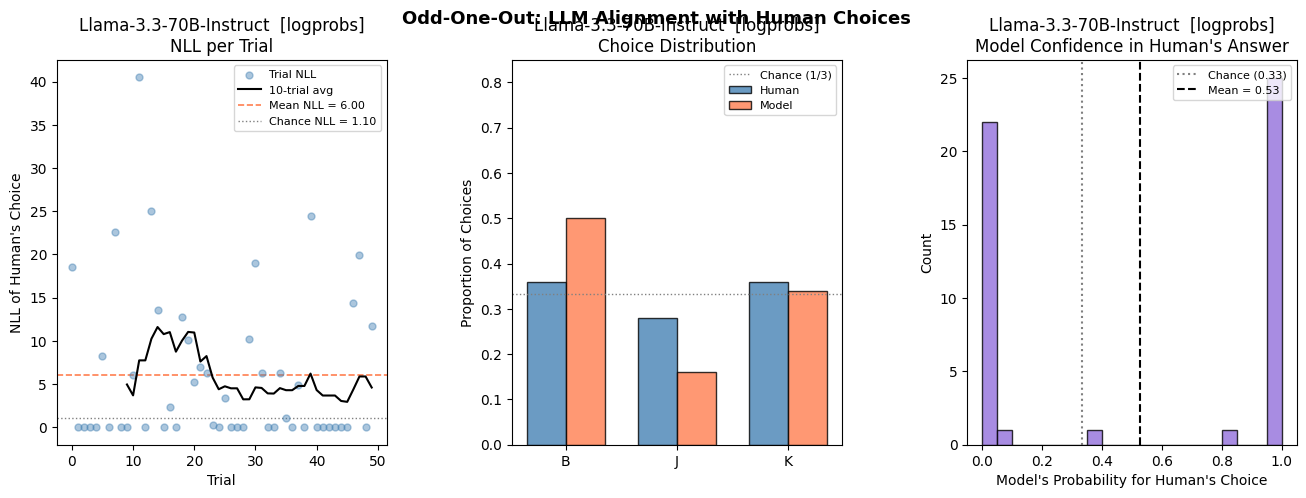

In [66]:
for model_id, results in all_results.items():
    df = pd.DataFrame(results)
    plot_results(
        df,
        model_id    = model_id,
        method_label= "logprobs",
        save_path   = f"odd_one_out_{model_id.replace('/', '_')}.png"
    )

---
## 8. Save Results to CSV

Save all trial-level data for later analysis.

In [36]:
all_dfs = []
for model_id, results in all_results.items():
    df = pd.DataFrame(results)
    df["model"] = model_id
    all_dfs.append(df)

combined_df = pd.concat(all_dfs, ignore_index=True)
combined_df.to_csv("odd_one_out_results.csv", index=False)
print(f"Saved {len(combined_df)} trial records to odd_one_out_results.csv")
combined_df.head()

Saved 50 trial records to odd_one_out_results.csv


,trial_idx,B,J,K,human_choice,model_choice,lp_B,lp_J,lp_K,prob_B,prob_J,prob_K,nll,correct,model
0,0,prune,nail polish,diskette,K,B,0.000000,-17.135418,-18.593750,1.000000e+00,3.615618e-08,8.410793e-09,18.593750,False,Llama-3.3-70B-Instruct
1,1,ladle,water bottle,pug,K,K,-20.364586,-38.489586,0.000000,1.431439e-09,1.923912e-17,1.000000e+00,-0.000000,True,Llama-3.3-70B-Instruct
2,2,punch,hair,lollipop,J,J,-5.576707,-0.003793,-14.326711,3.785010e-03,9.962144e-01,5.997754e-07,0.003793,True,Llama-3.3-70B-Instruct
3,3,oar,mug,macaroni,B,B,-0.003601,-5.628601,-14.066105,9.964056e-01,3.593599e-03,7.783381e-07,0.003601,True,Llama-3.3-70B-Instruct
4,4,towel,hot tub,mallet,K,K,-6.615926,-27.345089,-0.001340,1.338875e-03,1.331002e-12,9.986611e-01,0.001340,True,Llama-3.3-70B-Instruct


---
## 9. Inspect Disagreements

Look at the specific trials where model and human disagree most — useful for qualitative analysis.

In [37]:
for model_id, results in all_results.items():
    df = pd.DataFrame(results)
    disagreements = df[df["correct"] == False].copy()
    disagreements = disagreements.sort_values("nll", ascending=False).head(10)

    print(f"\n=== Top disagreements for {model_id} ===")
    print(f"{'B':20s} {'J':20s} {'K':20s} {'Human':7s} {'Model':7s} {'NLL':6s}")
    print("-" * 80)
    for _, row in disagreements.iterrows():
        print(f"{row['B']:20s} {row['J']:20s} {row['K']:20s} "
              f"{row['human_choice']:7s} {row['model_choice']:7s} {row['nll']:.3f}")


=== Top disagreements for Llama-3.3-70B-Instruct ===
B                    J                    K                    Human   Model   NLL   
--------------------------------------------------------------------------------
boy                  burrito              microscope           J       K       40.521
forklift             clipper              hip                  J       K       25.055
bun                  snow                 tinsel               J       B       24.479
straw                sweeper              baton                J       B       22.656
aircraft carrier     prism                turban               K       B       19.896
face mask            cinnamon             toilet paper         B       J       19.062
prune                nail polish          diskette             K       B       18.594
bunkbed              tractor              windshield           B       J       14.375
candelabra           beard                glue                 J       B       13.554
knee 

---
## 10. Next Steps

Now that this text-only pipeline is working, you can extend it in several ways:

1. **More trials / more participants** — increase `N_TRIALS` and `MAX_PARTICIPANTS`
2. **More models** — add any model available on the Brown LiteLLM API to `MODELS_TO_TEST`
3. **Vision extension** — replace word labels with actual images of the objects (requires a VLM like GPT-5.2 and sourcing THINGS images)
4. **Participant-level analysis** — group by `participant_id` to ask whether alignment varies across individuals
5. **Triplet difficulty** — use human agreement rate per triplet as a proxy for difficulty; check whether model alignment is higher on "easy" (high-agreement) triplets
6. **Embedding comparison** — compare the model's choice distributions to cosine similarity from word embeddings (e.g., GloVe) as an additional baseline

---
## 11. Vision Extension: Odd-One-Out with Images

Instead of sending the words "B: prune, J: nail polish, K: diskette", we send **actual photos** of those objects to a vision-capable model (VLM). Everything else — logprob extraction, NLL, analysis — stays identical.

### Setup: Download THINGS Images

The Psych-101 odd-one-out experiment uses concepts from the **THINGS** object database (Hebart et al., 2019). Images are freely available:

```
pip install requests
```

Then download the image set from:  
**https://osf.io/jum2f/** → download `object_images_v2.zip` → unzip into a folder called `things_images/` inside this repo directory.

The folder structure should look like:
```
things_images/
  alarm clock/
    alarm clock_01b.jpg
    alarm clock_02b.jpg
    ...
  prune/
    prune_01b.jpg
  ...
```

Each concept has its own subfolder. We pick the first image in each subfolder.

> **Note:** If images aren't downloaded yet, the cells below will fall back to text labels gracefully.

In [67]:
import base64
import glob

# Point this to wherever you unzipped the THINGS images
THINGS_IMAGE_DIR = "things_images"


def find_image_for_concept(word):
    """
    Given a THINGS concept word (e.g. "nail polish"), find the first matching
    image file under THINGS_IMAGE_DIR.

    THINGS images live in per-concept subfolders:
        things_images/nail polish/nail polish_01b.jpg

    Returns the file path string, or None if not found.
    """
    word_clean = word.lower().strip()

    # Try exact subfolder match first
    exact = os.path.join(THINGS_IMAGE_DIR, word_clean)
    if os.path.isdir(exact):
        imgs = sorted(glob.glob(os.path.join(exact, "*.jpg")) +
                      glob.glob(os.path.join(exact, "*.png")))
        if imgs:
            return imgs[0]

    # Fuzzy fallback: find any subfolder whose name starts with the word
    try:
        for subfolder in os.listdir(THINGS_IMAGE_DIR):
            if subfolder.lower().startswith(word_clean):
                full = os.path.join(THINGS_IMAGE_DIR, subfolder)
                if os.path.isdir(full):
                    imgs = sorted(glob.glob(os.path.join(full, "*.jpg")) +
                                  glob.glob(os.path.join(full, "*.png")))
                    if imgs:
                        return imgs[0]
    except FileNotFoundError:
        pass  # THINGS_IMAGE_DIR doesn't exist yet

    return None


def encode_image_b64(image_path):
    """Base64-encode an image file for the API."""
    with open(image_path, "rb") as f:
        data = base64.b64encode(f.read()).decode("utf-8")
    ext = image_path.rsplit(".", 1)[-1].lower()
    mime = "image/jpeg" if ext in ("jpg", "jpeg") else "image/png"
    return data, mime


# Quick coverage check: how many of our trial words have images?
if all_trials:
    words = set()
    for t in trial_subset:
        words.update([t["B"], t["J"], t["K"]])

    found = sum(1 for w in words if find_image_for_concept(w) is not None)
    total = len(words)
    print(f"Image coverage: {found}/{total} unique words have images ({100*found/total:.0f}%)")
    if found == 0:
        print("\nNo images found yet. Download THINGS images per the instructions above.")
        print("The vision runner below will fall back to text labels for missing images.")

Image coverage: 113/144 unique words have images (78%)


In [68]:
def count_images_for_trial(trial):
    """Return how many of B/J/K have a THINGS image available (0–3)."""
    return sum(1 for k in ["B", "J", "K"] if find_image_for_concept(trial[k]) is not None)


def select_vision_trials(trials, n, seed=None):
    """
    Select n trials for a vision experiment, prioritising image coverage.

    Priority order (within each tier trials are shuffled randomly):
        Tier 3 — all 3 images found  → fully visual, zero text word labels
        Tier 2 — 2 images found      → one text fallback
        Tier 1 — 1 image found       → two text fallbacks
        Tier 0 — no images found     → all text (same as text-only pipeline)

    The function fills from Tier 3 downward until n trials are collected,
    so if there are enough 3-image trials you never dip into lower tiers.

    Returns
    -------
    selected  : list of trial dicts
    coverage  : dict summarising image coverage of the selection
    """
    rng = random.Random(seed)

    tiers = {3: [], 2: [], 1: [], 0: []}
    for t in trials:
        tiers[count_images_for_trial(t)].append(t)

    for tier_list in tiers.values():
        rng.shuffle(tier_list)

    selected = []
    for tier in [3, 2, 1, 0]:
        needed = n - len(selected)
        if needed <= 0:
            break
        selected.extend(tiers[tier][:needed])

    n_full = sum(1 for t in selected if count_images_for_trial(t) == 3)
    n_part = sum(1 for t in selected if 0 < count_images_for_trial(t) < 3)
    n_none = sum(1 for t in selected if count_images_for_trial(t) == 0)

    coverage = {
        "n_image_only":    n_full,
        "n_partial_image": n_part,
        "n_text_only":     n_none,
        "pct_image_only":  n_full / len(selected) if selected else 0.0,
    }

    print(f"Trial selection ({len(selected)} total): "
          f"{n_full} fully visual | {n_part} partial | {n_none} text-only")

    return selected, coverage

In [69]:
def build_trial_prompt_vision(trial):
    """
    Build a multimodal message content list for a single trial.

    For each key (B, J, K):
      - If a THINGS image exists for that word: send the image with a key label
      - If not: fall back to the text label (same as text-only pipeline)

    Returns a list of content blocks suitable for the 'content' field
    of an OpenAI chat message.
    """
    content = []

    for key in ["B", "J", "K"]:
        word = trial[key]
        img_path = find_image_for_concept(word)

        if img_path:
            b64_data, mime = encode_image_b64(img_path)
            content.append({
                "type": "text",
                "text": f"{key}:"
            })
            content.append({
                "type": "image_url",
                "image_url": {"url": f"data:{mime};base64,{b64_data}"}
            })
        else:
            # Graceful text fallback
            content.append({
                "type": "text",
                "text": f"{key}: {word}"
            })

    content.append({
        "type": "text",
        "text": "\nWhich object is the odd one out — least similar to the other two? Reply with only B, J, or K."
    })

    return content


# Preview the structure for the first trial
preview = build_trial_prompt_vision(all_trials[0])
for block in preview:
    if block["type"] == "text":
        print(f"[text]  {block['text']}")
    else:
        url_preview = block["image_url"]["url"][:60]
        print(f"[image] {url_preview}...")

[text]  B:
[image] data:image/jpeg;base64,/9j/4SsGRXhpZgAATU0AKgAAAAgADAEAAAMAA...
[text]  J: nail polish
[text]  K:
[image] data:image/jpeg;base64,/9j/4RQgRXhpZgAATU0AKgAAAAgADAEAAAMAA...
[text]  
Which object is the odd one out — least similar to the other two? Reply with only B, J, or K.


In [70]:
def run_odd_one_out_vision(model_id, trials, verbose=False):
    """
    Same as run_odd_one_out() but sends images (or text fallback) instead of
    plain text labels. Only works with vision-capable models.

    Adds one extra field to each result dict:
        'n_images': int — how many of the 3 slots were sent as images (vs text fallback)
    """
    results = []

    for i, trial in enumerate(tqdm(trials, desc=f"{model_id} [vision]")):
        content = build_trial_prompt_vision(trial)

        # Count how many image blocks are in this trial's prompt
        n_images = sum(1 for block in content if block["type"] == "image_url")

        try:
            response = client.chat.completions.create(
                model=model_id,
                messages=[
                    {"role": "system", "content": ODD_ONE_OUT_SYSTEM_PROMPT},
                    {"role": "user",   "content": content}   # <-- list, not string
                ],
                logprobs=True,
                top_logprobs=5,
                reasoning_effort=None,
                max_tokens=5
            )
        except Exception as e:
            print(f"  API error on trial {i}: {e}")
            continue

        lp_map       = extract_option_logprobs(response)
        prob_map     = softmax_from_logprobs(lp_map)
        model_choice = get_model_choice(lp_map)
        nll          = get_nll(lp_map, trial["human_choice"])

        result = {
            "trial_idx":    i,
            "B":            trial["B"],
            "J":            trial["J"],
            "K":            trial["K"],
            "human_choice": trial["human_choice"],
            "model_choice": model_choice,
            "lp_B":         lp_map["B"],
            "lp_J":         lp_map["J"],
            "lp_K":         lp_map["K"],
            "prob_B":       prob_map["B"],
            "prob_J":       prob_map["J"],
            "prob_K":       prob_map["K"],
            "nll":          nll,
            "correct":      model_choice == trial["human_choice"],
            "n_images":     n_images,   # 0 = full text fallback, 3 = full vision
        }
        results.append(result)

        if verbose:
            mode = f"[{n_images}/3 images]"
            print(f"  [{i}] {mode} B={trial['B']:12s} J={trial['J']:12s} K={trial['K']:12s} "
                  f"| Human={trial['human_choice']} Model={model_choice} NLL={nll:.3f}")

    return results

In [ ]:
# ── Vision Configuration ──────────────────────────────────────────────────────
VISION_MODEL       = "gpt-5.2"
N_TRIALS_VISION    = 50
VISION_SEED        = 42
# ─────────────────────────────────────────────────────────────────────────────

vision_trial_subset, vision_coverage = select_vision_trials(
    all_trials, N_TRIALS_VISION, seed=VISION_SEED
)

print(f"\nRunning vision experiment: {VISION_MODEL} on {len(vision_trial_subset)} trials...")
vision_results = run_odd_one_out_vision(VISION_MODEL, vision_trial_subset, verbose=True)

vision_df = pd.DataFrame(vision_results)
print(f"\n--- Vision Results: {VISION_MODEL} ---")
print(f"  Top-1 accuracy (vs human): {vision_df['correct'].mean():.3f}")
print(f"  Mean NLL:                  {vision_df['nll'].mean():.3f}")
print(f"  Fully image-only trials:   {vision_coverage['n_image_only']}/{len(vision_trial_subset)}"
      f" ({vision_coverage['pct_image_only']:.0%})")
print(f"  Partial image trials:      {vision_coverage['n_partial_image']}/{len(vision_trial_subset)}")
print(f"  Text-only fallback trials: {vision_coverage['n_text_only']}/{len(vision_trial_subset)}")

In [ ]:
# ── Compare text vs vision on the same trials and same model ────────────────
# Run the text-only version of the same model for a direct apples-to-apples comparison.
# This tells you: does seeing the actual image change the model's similarity judgments?

print(f"Running text-only version of {VISION_MODEL} for comparison...")
text_results_vlm = run_odd_one_out(VISION_MODEL, vision_trial_subset, verbose=False)
text_df_vlm = pd.DataFrame(text_results_vlm)
text_df_vlm["modality"] = "text"
vision_df["modality"] = "vision"

comparison_df = pd.concat([text_df_vlm, vision_df], ignore_index=True)

print("\n=== Text vs Vision Comparison ===")
print(comparison_df.groupby("modality")[["correct", "nll"]].agg(["mean", "std"]).round(3))

# Agreement between text and vision versions (same trial, same model)
text_choices  = text_df_vlm.set_index("trial_idx")["model_choice"]
vision_choices = vision_df.set_index("trial_idx")["model_choice"]
shared_idx = text_choices.index.intersection(vision_choices.index)
agreement = (text_choices[shared_idx] == vision_choices[shared_idx]).mean()
print(f"\nText-Vision agreement (same model, same trials): {agreement:.3f}")
print("(1.0 = identical choices; lower = images change the model's mind)")

# Save combined results
comparison_df.to_csv("odd_one_out_vision_comparison.csv", index=False)
print("\nSaved to odd_one_out_vision_comparison.csv")

---
## 12. Repeated Sampling — For Models Without Logprobs (e.g. Gemini)

Some models (Gemini, some others) don't expose token-level log probabilities through the API. To still get a probability distribution over B/J/K, we use **repeated sampling**: ask the model the same question `N_SAMPLES` times at `temperature=1.0` and count how often it picks each option. Those frequencies are our probability estimates.

For example, if across 20 samples a model picks B 14 times, J 4 times, K 2 times → estimated probs are 0.70 / 0.20 / 0.10, and NLL for a human who picked J would be `-log(0.20) = 1.61`.

This is noisier than true logprobs but scientifically valid. More samples = more accurate estimates. 20 is a reasonable default; 50 is better if budget allows.

In [73]:
def parse_single_token_response(text):
    """
    Extract a B/J/K answer from free-form model output.
    Handles cases where the model outputs extra text despite instructions.
    Returns the first valid key found, or None.
    """
    text = text.strip()
    # Check the first character first (ideal case)
    if text and text[0].upper() in VALID_KEYS:
        return text[0].upper()
    # Scan for any standalone B, J, or K
    for char in text.upper():
        if char in VALID_KEYS:
            return char
    return None


def run_odd_one_out_sampling(model_id, trials, n_samples=20, temperature=1.0,
                              use_vision=False, verbose=False):
    """
    Run the odd-one-out experiment using repeated sampling instead of logprobs.
    Works with any model, including those that don't support logprobs (e.g. Gemini).

    For each trial, calls the API `n_samples` times and counts how often
    each of B/J/K is chosen. Those counts become the probability estimates.

    Parameters
    ----------
    model_id    : str   — model to query
    trials      : list  — list of trial dicts
    n_samples   : int   — number of samples per trial (more = better estimates)
    temperature : float — sampling temperature (must be > 0)
    use_vision  : bool  — if True, send images via build_trial_prompt_vision
                          (model must be a VLM and THINGS images must be downloaded)
    verbose     : bool  — print trial-by-trial output

    Returns a list of result dicts with the same schema as run_odd_one_out(),
    plus an extra field:
        'n_samples':       int   — how many valid responses were collected
        'n_parsed_failed': int   — how many responses couldn't be parsed
    """
    results = []

    for i, trial in enumerate(tqdm(trials, desc=f"{model_id} [sampling x{n_samples}]")):

        if use_vision:
            content = build_trial_prompt_vision(trial)
        else:
            content = build_trial_prompt(trial)

        counts = {"B": 0, "J": 0, "K": 0}
        n_failed = 0

        for _ in range(n_samples):
            try:
                response = client.chat.completions.create(
                    model=model_id,
                    messages=[
                        {"role": "system", "content": ODD_ONE_OUT_SYSTEM_PROMPT},
                        {"role": "user",   "content": content}
                    ],
                    temperature=temperature,
                    max_tokens=5,
                    # Do NOT request logprobs — not needed and may error on some models
                )
                raw = response.choices[0].message.content or ""
                key = parse_single_token_response(raw)
                if key:
                    counts[key] += 1
                else:
                    n_failed += 1
            except Exception as e:
                n_failed += 1
                if verbose:
                    print(f"    sample error on trial {i}: {e}")

        total_valid = sum(counts.values())
        if total_valid == 0:
            print(f"  Warning: all {n_samples} samples failed on trial {i}, skipping.")
            continue

        # Estimated probabilities from sample counts
        # Add a small smoothing value (0.01) to avoid log(0) for unseen options
        smooth = 0.01
        prob_map = {
            k: (counts[k] + smooth) / (total_valid + smooth * len(VALID_KEYS))
            for k in VALID_KEYS
        }

        model_choice = max(counts, key=counts.get)
        human_lp     = math.log(prob_map[trial["human_choice"]])
        nll          = -human_lp

        result = {
            "trial_idx":       i,
            "B":               trial["B"],
            "J":               trial["J"],
            "K":               trial["K"],
            "human_choice":    trial["human_choice"],
            "model_choice":    model_choice,
            "lp_B":            math.log(prob_map["B"]),
            "lp_J":            math.log(prob_map["J"]),
            "lp_K":            math.log(prob_map["K"]),
            "prob_B":          prob_map["B"],
            "prob_J":          prob_map["J"],
            "prob_K":          prob_map["K"],
            "nll":             nll,
            "correct":         model_choice == trial["human_choice"],
            "n_samples":       total_valid,
            "n_parse_failed":  n_failed,
        }
        results.append(result)

        if verbose:
            print(f"  [{i}] B={trial['B']:12s} J={trial['J']:12s} K={trial['K']:12s} "
                  f"counts={counts} | Human={trial['human_choice']} "
                  f"Model={model_choice} NLL={nll:.3f}")

    return results

In [72]:
# ── Configuration ─────────────────────────────────────────────────────────────
SAMPLING_MODEL       = "gemini-3-flash-preview"
N_TRIALS_SAMPLING    = 10
N_SAMPLES_PER_TRIAL  = 10
SAMPLING_SEED        = 42
# ─────────────────────────────────────────────────────────────────────────────

sampling_trial_subset, sampling_coverage = select_vision_trials(
    all_trials, N_TRIALS_SAMPLING, seed=SAMPLING_SEED
)

print(f"\nRunning: {SAMPLING_MODEL}  ({N_SAMPLES_PER_TRIAL} samples/trial)")
gemini_results = run_odd_one_out_sampling(
    model_id    = SAMPLING_MODEL,
    trials      = sampling_trial_subset,
    n_samples   = N_SAMPLES_PER_TRIAL,
    temperature = 1.0,
    use_vision  = False,   # flip to True once THINGS images are downloaded
    verbose     = True,
)

gemini_df = pd.DataFrame(gemini_results)
print(f"\n--- Results: {SAMPLING_MODEL} (sampling n={N_SAMPLES_PER_TRIAL}) ---")
print(f"  Top-1 accuracy (vs human): {gemini_df['correct'].mean():.3f}")
print(f"  Mean NLL:                  {gemini_df['nll'].mean():.3f}  (chance = {math.log(3):.3f})")
print(f"  Mean parse failures/trial: {gemini_df['n_parse_failed'].mean():.1f}")
print(f"  Fully image-only trials:   {sampling_coverage['n_image_only']}/{len(sampling_trial_subset)}"
      f" ({sampling_coverage['pct_image_only']:.0%})")
print(f"  Partial image trials:      {sampling_coverage['n_partial_image']}/{len(sampling_trial_subset)}")
print(f"  Text-only fallback trials: {sampling_coverage['n_text_only']}/{len(sampling_trial_subset)}")

Trial selection (10 total): 10 fully visual | 0 partial | 0 text-only

Running: gemini-3-flash-preview  (10 samples/trial)


gemini-3-flash-preview [sampling x10]:  10%|████▊                                           | 1/10 [00:02<00:24,  2.68s/it]

  [0] B=scone        J=pie          K=ant          counts={'B': 0, 'J': 0, 'K': 10} | Human=K Model=K NLL=0.002


gemini-3-flash-preview [sampling x10]:  20%|█████████▌                                      | 2/10 [00:04<00:15,  1.92s/it]

  [1] B=bag          J=eel          K=trampoline   counts={'B': 0, 'J': 10, 'K': 0} | Human=J Model=J NLL=0.002


...

  [7] B=maggot       J=mouth        K=stockings    counts={'B': 0, 'J': 0, 'K': 10} | Human=B Model=K NLL=6.911


gemini-3-flash-preview [sampling x10]:  90%|███████████████████████████████████████████▏    | 9/10 [00:31<00:04,  4.32s/it]

  [8] B=tortellini   J=cantaloupe   K=sequin       counts={'B': 0, 'J': 0, 'K': 10} | Human=K Model=K NLL=0.002


gemini-3-flash-preview [sampling x10]: 100%|███████████████████████████████████████████████| 10/10 [00:32<00:00,  3.28s/it]

  [9] B=bun          J=snow         K=tinsel       counts={'B': 10, 'J': 0, 'K': 0} | Human=J Model=B NLL=6.911

--- Results: gemini-3-flash-preview (sampling n=10) ---
  Top-1 accuracy (vs human): 0.400
  Mean NLL:                  4.147  (chance = 1.099)
  Mean parse failures/trial: 0.0
  Fully image-only trials:   10/10 (100%)
  Partial image trials:      0/10
  Text-only fallback trials: 0/10


Figure saved to odd_one_out_gemini-3-flash-preview.png


/var/folders/s5/_m1bnhhx2ys3mzb1lzg0wxg00000gn/T/ipykernel_9539/1652615681.py:79: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


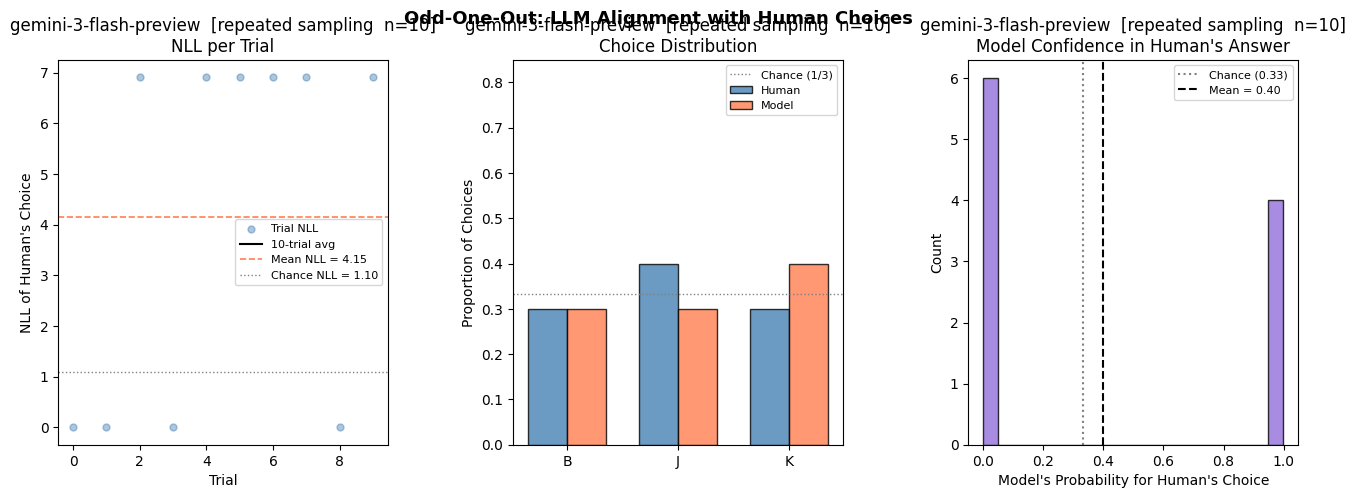

In [74]:
plot_results(
    gemini_df,
    model_id     = SAMPLING_MODEL,
    method_label = f"repeated sampling  n={N_SAMPLES_PER_TRIAL}",
    save_path    = f"odd_one_out_{SAMPLING_MODEL.replace('/', '_')}.png"
)

---
## 13. Image Prompt Logger

Saves an HTML file showing exactly what was sent to the vision model for each trial — the three images side-by-side with their B/J/K labels, sample counts, and human vs. model choice. Open `vision_prompt_log.html` in any browser to inspect it.

In [75]:
def save_vision_prompt_log(results, trials_used, model_id, coverage=None,
                           output_path="vision_prompt_log.html"):
    """
    Generate an HTML file showing every prompt sent to the vision model.

    Each trial card shows:
      - The 3 images side-by-side (base64 embedded) with B/J/K labels
      - A badge: "Image Only", "Partial (N/3)", or "Text Only"
      - Sample counts or logprobs for B/J/K
      - Human choice, model choice, NLL, correct/wrong

    A summary banner at the top reports overall image coverage.

    Parameters
    ----------
    results     : list of result dicts
    trials_used : list of trial dicts passed to the runner
    model_id    : str
    coverage    : dict from select_vision_trials (optional but recommended)
    output_path : str
    """

    def trial_image_html(word, key):
        img_path = find_image_for_concept(word)
        if img_path:
            b64, mime = encode_image_b64(img_path)
            return (
                f'<div class="img-slot">'
                f'  <div class="key-label">{key}</div>'
                f'  <img src="data:{mime};base64,{b64}" />'
                f'  <div class="word-label">{word}</div>'
                f'</div>'
            )
        else:
            return (
                f'<div class="img-slot text-fallback">'
                f'  <div class="key-label">{key}</div>'
                f'  <div class="word-text">{word}</div>'
                f'  <div class="word-label">(text fallback)</div>'
                f'</div>'
            )

    def coverage_badge(n_imgs):
        if n_imgs == 3:
            return '<span class="badge badge-full">Image Only</span>'
        elif n_imgs > 0:
            return f'<span class="badge badge-partial">Partial ({n_imgs}/3 images)</span>'
        else:
            return '<span class="badge badge-text">Text Only</span>'

    css = """
    body  { font-family: Arial, sans-serif; background: #f4f4f4; padding: 24px; }
    h1    { color: #222; margin-bottom: 4px; }
    .summary-banner {
        background: #fff; border-left: 5px solid #4a90d9; padding: 12px 18px;
        border-radius: 6px; margin-bottom: 24px; font-size: 14px; line-height: 1.8;
    }
    .trial-card {
        background: white; border-radius: 8px; padding: 16px; margin-bottom: 18px;
        box-shadow: 0 1px 4px rgba(0,0,0,0.1);
    }
    .trial-header { font-weight: bold; font-size: 14px; margin-bottom: 10px;
                    display: flex; align-items: center; gap: 10px; }
    .images-row   { display: flex; gap: 16px; margin-bottom: 12px; flex-wrap: wrap; }
    .img-slot     { text-align: center; min-width: 120px; }
    .img-slot img { width: 120px; height: 120px; object-fit: cover;
                    border-radius: 6px; border: 2px solid #ddd; display: block; margin: 0 auto; }
    .key-label    { font-size: 20px; font-weight: bold; color: #444; margin-bottom: 4px; }
    .word-label   { font-size: 11px; color: #999; margin-top: 4px; }
    .word-text    { font-size: 15px; font-weight: bold; padding: 38px 10px;
                    background: #eef3ff; border-radius: 6px; min-width: 100px; color: #333; }
    .text-fallback { opacity: 0.85; }
    .stats        { font-size: 13px; color: #444; margin-bottom: 6px; }
    .correct      { color: #27ae60; font-weight: bold; }
    .wrong        { color: #c0392b; font-weight: bold; }
    .counts-bar   { display: flex; gap: 8px; flex-wrap: wrap; }
    .count-item   { background: #f0f4ff; border-radius: 4px; padding: 3px 10px; font-size: 12px; }
    .badge        { padding: 2px 9px; border-radius: 12px; font-size: 11px; font-weight: bold; }
    .badge-full   { background: #d4edda; color: #155724; }
    .badge-partial{ background: #fff3cd; color: #856404; }
    .badge-text   { background: #f8d7da; color: #721c24; }
    """

    rows_html = []
    result_by_idx = {r["trial_idx"]: r for r in results}

    for i, trial in enumerate(trials_used):
        r = result_by_idx.get(i)
        if r is None:
            continue

        n_imgs       = count_images_for_trial(trial)
        correct_cls  = "correct" if r["correct"] else "wrong"
        correct_str  = "✓ Correct" if r["correct"] else "✗ Wrong"

        if "n_samples" in r:
            total = r.get("n_samples", 20)
            counts_html = "".join(
                f'<span class="count-item">'
                f'{k}: {round(r[f"prob_{k}"] * total)}/{total} (p={r[f"prob_{k}"]:.2f})'
                f'</span>'
                for k in sorted(VALID_KEYS)
            )
            method_str = f"sampling (n={r['n_samples']})"
        else:
            counts_html = "".join(
                f'<span class="count-item">'
                f'{k}: lp={r[f"lp_{k}"]:.2f}  p={r[f"prob_{k}"]:.2f}'
                f'</span>'
                for k in sorted(VALID_KEYS)
            )
            method_str = "logprobs"

        images_html = "".join(trial_image_html(trial[k], k) for k in ["B", "J", "K"])

        rows_html.append(f"""
        <div class="trial-card">
            <div class="trial-header">
                Trial {i + 1}
                {coverage_badge(n_imgs)}
            </div>
            <div class="images-row">{images_html}</div>
            <div class="stats">
                <b>Human:</b> {r['human_choice']} ({trial[r['human_choice']]}) &nbsp;|&nbsp;
                <b>Model:</b> {r['model_choice']} ({trial[r['model_choice']]}) &nbsp;|&nbsp;
                <span class="{correct_cls}">{correct_str}</span> &nbsp;|&nbsp;
                <b>NLL:</b> {r['nll']:.3f} &nbsp;|&nbsp;
                <b>Method:</b> {method_str}
            </div>
            <div class="counts-bar">{counts_html}</div>
        </div>
        """)

    # Build coverage summary banner
    n_total   = len(rows_html)
    acc       = sum(r["correct"] for r in results) / len(results) if results else 0
    mean_nll  = sum(r["nll"] for r in results) / len(results) if results else float("nan")

    if coverage:
        cov_html = (
            f'<b>Image coverage:</b> '
            f'{coverage["n_image_only"]} fully visual '
            f'({coverage["pct_image_only"]:.0%}) &nbsp;|&nbsp; '
            f'{coverage["n_partial_image"]} partial &nbsp;|&nbsp; '
            f'{coverage["n_text_only"]} text-only<br>'
        )
    else:
        n_full = sum(1 for t in trials_used if count_images_for_trial(t) == 3)
        cov_html = f'<b>Fully visual trials:</b> {n_full}/{n_total}<br>'

    banner = f"""
    <div class="summary-banner">
        <b>Model:</b> {model_id} &nbsp;|&nbsp;
        <b>Trials:</b> {n_total} &nbsp;|&nbsp;
        <b>Accuracy:</b> {acc:.1%} &nbsp;|&nbsp;
        <b>Mean NLL:</b> {mean_nll:.3f} (chance = {math.log(3):.3f})<br>
        {cov_html}
        <b>Note:</b> "Image Only" trials contain no text word labels —
        the model saw only photos labeled B / J / K.
        "Partial" trials had at least one text fallback. "Text Only" had no images.
    </div>
    """

    html = f"""<!DOCTYPE html>
<html><head>
<meta charset="utf-8">
<title>Vision Prompt Log — {model_id}</title>
<style>{css}</style>
</head><body>
<h1>Vision Prompt Log — {model_id}</h1>
{banner}
{"".join(rows_html)}
</body></html>"""

    with open(output_path, "w", encoding="utf-8") as f:
        f.write(html)

    print(f"Saved → {output_path}  ({n_total} trials, "
          f"{coverage['n_image_only'] if coverage else '?'} fully visual)")

In [76]:
# Run this after any vision or sampling experiment to generate the prompt log.

save_vision_prompt_log(
    results     = gemini_results,
    trials_used = sampling_trial_subset,
    model_id    = SAMPLING_MODEL,
    coverage    = sampling_coverage,
    output_path = "vision_prompt_log.html"
)

# For a logprob-based vision run, swap in:
# save_vision_prompt_log(vision_results, vision_trial_subset, VISION_MODEL,
#                        coverage=vision_coverage, output_path="vision_prompt_log_gpt.html")

Saved → vision_prompt_log.html  (10 trials, 10 fully visual)
